**Practice 5**<br>
Name: Jitesh Choudhary<br>
PRN: 1272240760

In [15]:
# STEP 1 & 2: START AND IMPORT REQUIRED LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print('Libraries imported successfully!')

Libraries imported successfully!


In [16]:
# STEP 3: LOAD THE DATASET
# Keep insurance.csv in the same folder as this notebook.

df = pd.read_csv('./insurance.csv')

print('Dataset loaded successfully!')

Dataset loaded successfully!


In [17]:
# STEP 4: DISPLAY DATASET INFORMATION

print('First 5 rows:')
display(df.head())

print('\nDataset Shape:')
print(df.shape)

print('\nColumn Names:')
print(df.columns.tolist())

print('\nData Types:')
print(df.dtypes)

print('\nMissing Values:')
print(df.isnull().sum())

print('\nStatistical Summary:')
display(df.describe())

First 5 rows:


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520



Dataset Shape:
(1338, 7)

Column Names:
['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']

Data Types:
age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

Missing Values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Statistical Summary:


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [18]:
# STEP 5 & 6: SELECT INPUT AND TARGET

# Independent variable / input
X = df[['bmi']]

# Dependent variable / target
y = df['charges']

print('Independent Variable: BMI')
print('Dependent Variable: Charges')
print('\nX shape:', X.shape)
print('y shape:', y.shape)

Independent Variable: BMI
Dependent Variable: Charges

X shape: (1338, 1)
y shape: (1338,)


In [19]:
# STEP 7: SPLIT DATA INTO 80% TRAINING AND 20% TESTING

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print('Training samples:', len(X_train))
print('Testing samples:', len(X_test))

Training samples: 1070
Testing samples: 268


In [20]:
# STEP 8: LINEAR REGRESSION BASELINE
# Degree = 1

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

y_pred_linear = linear_model.predict(X_test)

linear_r2 = r2_score(y_test, y_pred_linear)
linear_mae = mean_absolute_error(y_test, y_pred_linear)
linear_mse = mean_squared_error(y_test, y_pred_linear)
linear_rmse = np.sqrt(linear_mse)

print('==============================')
print('LINEAR REGRESSION BASELINE')
print('==============================')
print('Slope:', linear_model.coef_[0])
print('Intercept:', linear_model.intercept_)
print('R² Score:', linear_r2)
print('MAE:', linear_mae)
print('MSE:', linear_mse)
print('RMSE:', linear_rmse)

LINEAR REGRESSION BASELINE
Slope: 392.4365441698801
Intercept: 1353.0730722046574
R² Score: 0.03970193117941878
MAE: 9784.65259627133
MSE: 149085057.03839505
RMSE: 12210.039190698571


In [21]:
# STEP 9 & 10: POLYNOMIAL REGRESSION FUNCTION

def polynomial_regression(degree):
    # Generate polynomial features from BMI
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    # Train linear regression on polynomial features
    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    # Predictions
    y_train_pred = model.predict(X_train_poly)
    y_test_pred = model.predict(X_test_poly)

    # Evaluation metrics
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)
    test_rmse = np.sqrt(test_mse)

    return poly, model, y_test_pred, train_r2, test_r2, test_mae, test_mse, test_rmse

In [22]:
# STEP 10: TRAIN POLYNOMIAL MODELS FOR DEGREES 2, 3, 4 AND 5

degrees = [2, 3, 4, 5]
results = []
models = {}

for degree in degrees:
    (
        poly,
        model,
        predictions,
        train_r2,
        test_r2,
        mae,
        mse,
        rmse
    ) = polynomial_regression(degree)

    models[degree] = (poly, model)

    results.append([
        degree,
        train_r2,
        test_r2,
        mae,
        mse,
        rmse
    ])

print('Polynomial models trained successfully.')

Polynomial models trained successfully.


In [23]:
# STEP 11 & 12: CALCULATE METRICS AND COMPARE DIFFERENT DEGREES

results_df = pd.DataFrame(
    results,
    columns=['Degree', 'Training R2', 'Testing R2', 'MAE', 'MSE', 'RMSE']
)

print('==============================')
print('POLYNOMIAL REGRESSION RESULTS')
print('==============================')
display(results_df)

# Best degree according to testing R²
best_degree = results_df.loc[results_df['Testing R2'].idxmax(), 'Degree']
print(f'Best degree based on Testing R²: {int(best_degree)}')

POLYNOMIAL REGRESSION RESULTS


,Degree,Training R2,Testing R2,MAE,MSE,RMSE
0,2,0.041558,0.030763,9823.701955,1.504728e+08,12266.733504
1,3,0.045290,0.018011,9863.434995,1.524525e+08,12347.166300
2,4,0.045494,0.014597,9864.876317,1.529825e+08,12368.609295
3,5,0.045482,0.012994,9866.056436,1.532314e+08,12378.667905


Best degree based on Testing R²: 2


In [24]:
# STEP 13 & 14: PREDICT INSURANCE CHARGES FOR BMI = 30

new_bmi = np.array([[30]])

print('==============================')
print('PREDICTION FOR BMI = 30')
print('==============================')

prediction_results = []

for degree in degrees:
    poly, model = models[degree]
    new_bmi_poly = poly.transform(new_bmi)
    predicted_charge = model.predict(new_bmi_poly)[0]
    prediction_results.append([degree, predicted_charge])
    print(f'Degree {degree}: Predicted insurance charge = {predicted_charge:.2f}')

prediction_df = pd.DataFrame(
    prediction_results,
    columns=['Degree', 'Predicted Charge']
)

display(prediction_df)

PREDICTION FOR BMI = 30
Degree 2: Predicted insurance charge = 13569.38
Degree 3: Predicted insurance charge = 13275.11
Degree 4: Predicted insurance charge = 13209.50
Degree 5: Predicted insurance charge = 13206.14


c:\Users\Jites\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
c:\Users\Jites\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
c:\Users\Jites\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
c:\Users\Jites\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


,Degree,Predicted Charge
0,2,13569.384519
1,3,13275.107783
2,4,13209.496364
3,5,13206.139559


In [25]:
# OPTIONAL CHECK: DISPLAY THE POLYNOMIAL FEATURES
# This demonstrates how BMI is converted into BMI, BMI², BMI³, etc.

poly_demo = PolynomialFeatures(degree=3, include_bias=False)
demo_features = poly_demo.fit_transform(np.array([[20], [25], [30]]))

demo_df = pd.DataFrame(
    demo_features,
    columns=['BMI', 'BMI²', 'BMI³']
)

print('==============================')
print('POLYNOMIAL FEATURE GENERATION')
print('==============================')
display(demo_df)

POLYNOMIAL FEATURE GENERATION


,BMI,BMI²,BMI³
0,20.0,400.0,8000.0
1,25.0,625.0,15625.0
2,30.0,900.0,27000.0


## Visualization — Original BMI vs Charges
This corresponds to the relationship inspection before fitting the models.

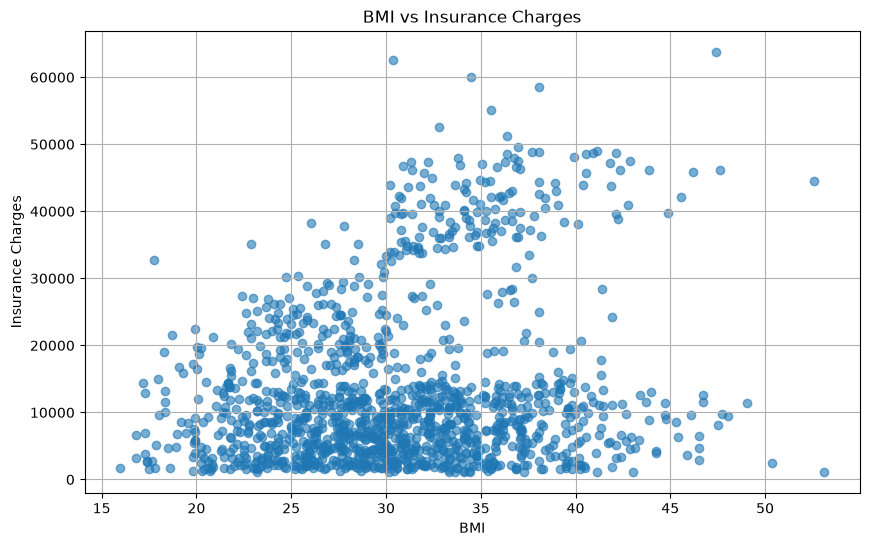

In [26]:
# VISUALIZE ORIGINAL DATA

plt.figure(figsize=(10, 6))
plt.scatter(X['bmi'], y, alpha=0.6)
plt.xlabel('BMI')
plt.ylabel('Insurance Charges')
plt.title('BMI vs Insurance Charges')
plt.grid(True)
plt.show()

## Visualization — Linear Regression Baseline

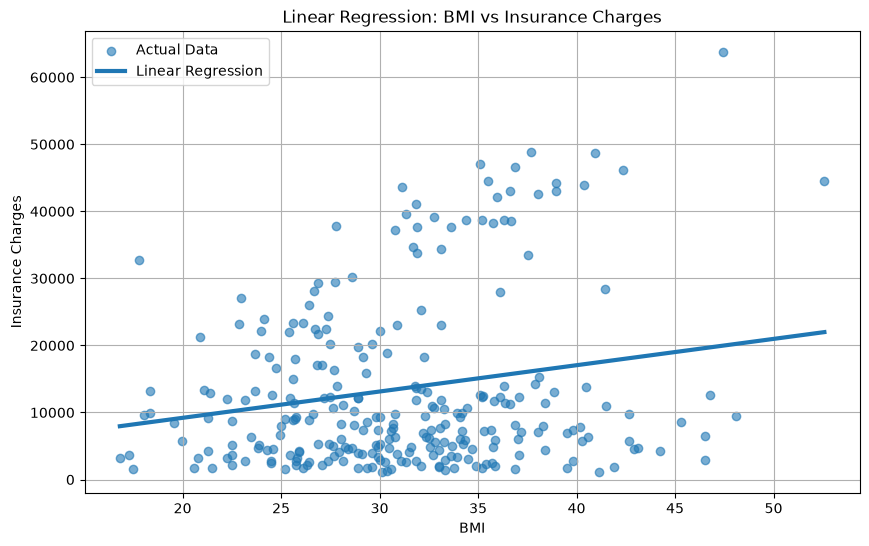

In [27]:
# PLOT LINEAR REGRESSION BASELINE

sort_index = np.argsort(X_test['bmi'].values)
X_test_sorted = X_test.iloc[sort_index]
y_linear_sorted = linear_model.predict(X_test_sorted)

plt.figure(figsize=(10, 6))
plt.scatter(X_test['bmi'], y_test, alpha=0.6, label='Actual Data')
plt.plot(
    X_test_sorted['bmi'],
    y_linear_sorted,
    linewidth=3,
    label='Linear Regression'
)
plt.xlabel('BMI')
plt.ylabel('Insurance Charges')
plt.title('Linear Regression: BMI vs Insurance Charges')
plt.legend()
plt.grid(True)
plt.show()

## Visualization — Polynomial Curves (Degree 2 to Degree 5)

c:\Users\Jites\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
c:\Users\Jites\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
c:\Users\Jites\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
c:\Users\Jites\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


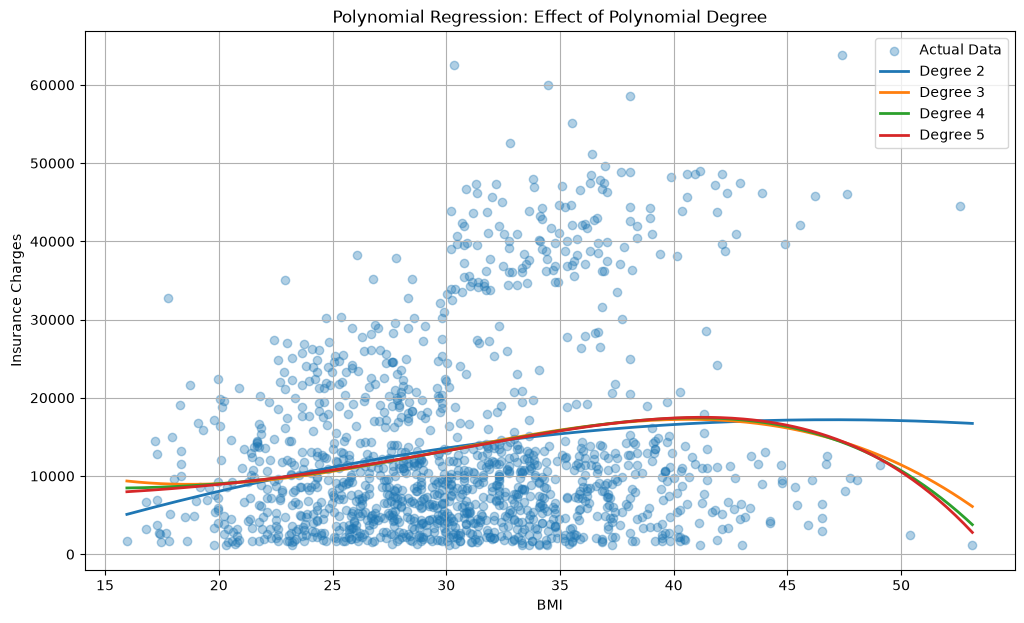

In [28]:
# STEP 12: PLOT POLYNOMIAL REGRESSION CURVES

bmi_range = np.linspace(
    X['bmi'].min(),
    X['bmi'].max(),
    300
).reshape(-1, 1)

plt.figure(figsize=(12, 7))
plt.scatter(X['bmi'], y, alpha=0.35, label='Actual Data')

for degree in degrees:
    poly, model = models[degree]
    bmi_poly = poly.transform(bmi_range)
    predictions = model.predict(bmi_poly)

    plt.plot(
        bmi_range,
        predictions,
        linewidth=2,
        label=f'Degree {degree}'
    )

plt.xlabel('BMI')
plt.ylabel('Insurance Charges')
plt.title('Polynomial Regression: Effect of Polynomial Degree')
plt.legend()
plt.grid(True)
plt.show()